In [1]:
from fungiclef._model._dataset import ImageDataset, EmbeddingDataset
from fungiclef._model.wrapper import FungiModel
from fungiclef._model.transforms import get_transforms
from fungiclef._model.utils import get_timm_model
from fungiclef.utils import get_spark, spark_resource, read_config
import pandas as pd

from torch.utils.data import DataLoader
import lightning as L
import torch
from fungiclef._model.loss import FungiModelLoss
import timm

# Load it to dataloader
BATCH_SIZE = 32
EPOCHS = 20
WORKERS = 4

train_df = pd.read_csv("../metadata_train_test.csv")
val_df = pd.read_csv("../metadata_val_test.csv")
test_df = pd.read_csv("../metadata_test.csv")

# train_df = pd.read_csv("../trial_metadata.csv")
# val_df = pd.read_csv("../trial_metadata.csv")
# test_df = pd.read_csv("../trial_metadata.csv")

# Load it as torch dataset
train_dataset = ImageDataset(
    train_df,
    local_filepath="../data/DF_FULL/",
    transform=get_transforms(data="train", width=224, height=224),
)
valid_dataset = ImageDataset(
    val_df, local_filepath="../data/DF_FULL/", transform=get_transforms(data="valid", width=384, height=384
))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=WORKERS,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=WORKERS,
)


ModuleNotFoundError: No module named 'fungiclef._model.wrapper'

In [5]:
import timm

In [8]:
model = timm.create_model('caformer_s18.sail_in22k', pretrained=True, num_classes=1605)

In [9]:
model

MetaFormer(
  (stem): Stem(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
    (norm): LayerNorm2dNoBias((64,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): MetaFormerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): MetaFormerBlock(
          (norm1): LayerNorm2dNoBias((64,), eps=1e-06, elementwise_affine=True)
          (token_mixer): SepConv(
            (pwconv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (act1): StarReLU(
              (relu): ReLU()
            )
            (dwconv): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128, bias=False)
            (act2): Identity()
            (pwconv2): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          )
          (drop_path1): Identity()
          (layer_scale1): Identity()
          (res_scale1): Identity()
          (norm2): LayerNorm2dNoBias((64,), eps=1e-06, e

In [3]:
import torch

weights = torch.load("../DSGT_FungiClef/metaformer-s-224.ckpt")['state_dict']

In [11]:
torch.load("../checkpoints/epoch=0-step=234.ckpt").keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'hparams_name', 'hyper_parameters'])

In [6]:
weights

OrderedDict([('model.stem.conv.weight',
              tensor([[[[-1.3556e-03,  7.4394e-03,  1.8359e-02,  ...,  1.0177e-02,
                          1.1818e-02,  3.8677e-03],
                        [ 4.4235e-03,  1.8735e-02,  2.3961e-02,  ...,  1.7438e-02,
                          1.2764e-02,  7.8241e-03],
                        [-9.1738e-03, -5.7022e-03,  1.9047e-02,  ...,  2.4576e-02,
                          2.3799e-02,  2.9591e-02],
                        ...,
                        [-2.0958e-02, -5.2555e-02, -3.7316e-02,  ...,  4.2428e-02,
                          4.4513e-02,  2.7345e-02],
                        [-1.3902e-02, -2.4215e-02, -1.7065e-02,  ..., -8.5341e-03,
                          1.8862e-02, -6.8348e-03],
                        [-4.6761e-03, -1.3892e-02, -1.7494e-02,  ..., -1.8009e-02,
                         -1.9897e-02, -2.7978e-02]],
              
                       [[-6.4992e-03, -2.5969e-03, -8.6137e-04,  ..., -1.1525e-02,
                      

In [16]:
import timm
weights = torch.load('metaformer-s-224.pth')
model = timm.create_model('caformer_s18.sail_in22k', pretrained=True, num_classes=1605)
model.load_state_dict({w.replace("model.", ""): v for w, v in weights.items()})

<All keys matched successfully>

<All keys matched successfully>

In [133]:
model_2 = timm.create_model('caformer_b36.sail_in22k_ft_in1k', pretrained=True, num_classes=1605)

In [134]:
model = timm.create_model('caformer_b36.sail_in22k', pretrained=True, num_classes=0)

In [135]:
model

MetaFormer(
  (stem): Stem(
    (conv): Conv2d(3, 128, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
    (norm): LayerNorm2dNoBias((128,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): MetaFormerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): MetaFormerBlock(
          (norm1): LayerNorm2dNoBias((128,), eps=1e-06, elementwise_affine=True)
          (token_mixer): SepConv(
            (pwconv1): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (act1): StarReLU(
              (relu): ReLU()
            )
            (dwconv): Conv2d(256, 256, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=256, bias=False)
            (act2): Identity()
            (pwconv2): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          )
          (drop_path1): Identity()
          (layer_scale1): Identity()
          (res_scale1): Identity()
          (norm2): LayerNorm2dNoBias((128,), eps=1e

In [136]:
# Use our wrapper module to get a PyTorch Lightning trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger

wandb_logger = WandbLogger(log_model=False, project="FungiClef")

checkpoint_callback = ModelCheckpoint(
    dirpath="../checkpoints", save_top_k=2, monitor="valid_acc_cls"
)
trainer = L.Trainer(
    callbacks=[checkpoint_callback], logger=wandb_logger, max_epochs=EPOCHS
)

# Class distribution for seesaw loss
class_distribution = []
c = val_df.class_id.value_counts()
for i in range(1605):
    class_distribution.append(c.get(i, 0))

# Try use focal loss
loss = FungiModelLoss(loss="cross_entropy", class_distribution=class_distribution)
module = FungiModel(
    model,
    loss=loss.loss,
    optimizer=torch.optim.AdamW(model.parameters(), lr=4e-3, weight_decay=0.05),
)

trainer.fit(module, train_loader, valid_loader)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
/home/chris/miniconda3/envs/fungiclef/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:653: Checkpoint directory /home/chris/fungiclef-2024/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                       | Type               | Params
----------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

RuntimeError: weight tensor should be defined either for all 768 classes or no classes but got weight tensor of shape: [1605]

In [ ]:
import os 
import cv2
from tqdm import tqdm 

good = []
bad = []

BASE_PATH = "../data/DF_FULL"
for file in tqdm(os.listdir("../data/DF_FULL")):
    with open(os.path.join(BASE_PATH, file), 'rb') as f:
        check_chars = f.read()[-2:]
        if check_chars != b'\xff\xd9':
            bad.append(file)
            continue
        
    

100%|██████████| 416996/416996 [02:04<00:00, 3343.72it/s]


In [ ]:
bad[0]

'0-3008823390.JPG'

In [ ]:
import pandas as pd 
train_df = pd.read_csv("../metadata_train.csv")
val_df = pd.read_csv("../metadata_val.csv")
test_df = pd.read_csv("../metadata_test.csv")


In [ ]:
bad[0] in list(val_df.image_path)

False

In [ ]:
len(bad)

1

In [ ]:
for b in bad:
    !mogrify "../data/DF_FULL/{b}"

In [ ]:
with open(os.path.join(BASE_PATH, file), 'rb') as f:
    b = f.read()[:100]

In [ ]:
str.decode(b, 'utf-8')

AttributeError: type object 'str' has no attribute 'decode'

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
len(bad)

416995

In [1]:
# fail = []
# for b in tqdm(bad):
#     try:
#         os.rename(os.path.join("../data/DF", b), os.path.join("../data/DF_FULL", b))
#     except Exception as e:
#         failed.append(b)

In [ ]:
with open(os.path.join(BASE_PATH, bad[0]), 'rb') as f:
        check_chars = f.read()[-2:]
        if check_chars != b'\xff\xd9':
            print("MEP")

In [ ]:
import pandas as pd

In [ ]:
test = pd.read_csv("../metadata_test.csv")
val = pd.read_csv("../metadata_val.csv")
train = pd.read_csv("../metadata_train.csv")

In [ ]:
val.class_id.value_counts()

class_id
1604    7463
937      153
1486     145
492      116
1437     102
        ... 
134        1
1444       1
1465       1
793        1
545        1
Name: count, Length: 737, dtype: int64

In [ ]:
train

,observationID,month,day,locality,level0Gid,level1Gid,level2Gid,Substrate,Latitude,Longitude,...,kingdom,phylum,class,order,family,genus,species,poisonous,class_id,dataset
0,2238506390,9.0,1.0,5179,9,28,80,24,55.781433,12.522967,...,1,2,0,81,168,0,0,0,0,train
1,2812984326,7.0,8.0,6157,9,32,146,6,55.381389,10.344444,...,1,2,0,81,168,0,0,0,0,train
2,2465026418,11.0,19.0,6829,9,31,139,6,55.234627,11.754908,...,1,2,0,81,168,0,0,0,0,train
3,2812994333,7.0,9.0,6145,9,32,146,6,55.391944,10.371944,...,1,2,0,81,168,0,0,0,0,train
4,2812983332,8.0,20.0,6157,9,32,146,6,55.381622,10.344847,...,1,2,0,81,168,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315327,2238482337,11.0,23.0,9621,9,29,98,7,56.037150,9.882307,...,1,2,0,2,291,181,2855,0,226,train
315328,2237940567,10.0,26.0,2012,9,29,111,7,56.448370,10.951630,...,1,2,0,2,291,181,2855,0,226,train
315329,2238455560,11.0,7.0,1662,9,29,108,7,55.776490,10.308890,...,1,2,0,2,291,181,2855,0,226,train
315330,2449442140,11.0,3.0,6116,9,31,133,7,54.644452,11.954001,...,1,2,0,2,291,181,2855,0,226,train


In [ ]:
_train = pd.concat((train, test))

In [ ]:
_train

,observationID,month,day,locality,level0Gid,level1Gid,level2Gid,Substrate,Latitude,Longitude,...,kingdom,phylum,class,order,family,genus,species,poisonous,class_id,dataset
0,2238506390,9.0,1.0,5179,9,28,80,24,55.781433,12.522967,...,1,2,0,81,168,0,0,0,0,train
1,2812984326,7.0,8.0,6157,9,32,146,6,55.381389,10.344444,...,1,2,0,81,168,0,0,0,0,train
2,2465026418,11.0,19.0,6829,9,31,139,6,55.234627,11.754908,...,1,2,0,81,168,0,0,0,0,train
3,2812994333,7.0,9.0,6145,9,32,146,6,55.391944,10.371944,...,1,2,0,81,168,0,0,0,0,train
4,2812983332,8.0,20.0,6157,9,32,146,6,55.381622,10.344847,...,1,2,0,81,168,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19741,3122827345,5.0,22.0,1237,9,28,89,6,55.319491,15.191356,...,1,2,0,48,257,959,2853,0,1604,test
19742,3313865303,6.0,26.0,2689,9,31,133,6,54.692814,11.841439,...,1,2,0,48,257,959,2853,0,1604,test
19743,3036779304,2.0,7.0,1682,9,32,148,6,55.047647,10.571918,...,1,2,0,48,257,959,2853,0,1604,test
19744,3131219325,6.0,13.0,4168,9,32,148,6,55.096751,10.560508,...,1,2,0,48,257,959,2853,0,1604,test


In [ ]:
import pandas as pd
train = pd.read_csv("../metadata_train.csv")

In [ ]:
public_test = pd.read_csv("../FungiCLEF2024_TestMetadata (2).csv")

In [ ]:
import torch 
weights = torch.load("/home/chris/fungiclef-2024/checkpoints/epoch=0-step=13139.ckpt")

In [30]:
import timm

model = timm.create_model('caformer_b36.sail_in22k', pretrained=True, num_classes=1605)


In [ ]:
model.load_state_dict({w.replace("model.", ""): v for w, v in weights['state_dict'].items()})

<All keys matched successfully>

In [ ]:
def geohash_base32_to_int(geohash):
    base32 = '0123456789bcdefghjkmnpqrstuvwxyz'
    num = 0
    for char in geohash:
        num = num * 32 + base32.index(char)
    return num

In [ ]:
df_all = pd.concat((train, val, test))

In [159]:
import pygeohash as pgh
from tqdm import tqdm

geohash_list = []
for _, row in tqdm(df_all.iterrows()):
    gh = pgh.encode(row.Latitude, row.Longitude)
    geohash_list.append(geohash_base32_to_int(gh[2:5]))



354866it [00:12, 29468.04it/s]


In [160]:
gh = pgh.encode(row.Latitude, row.Longitude)


In [165]:
base32 = '0123456789bcdefghjkmnpqrstuvwxyz'

base32.index(gh[0])

26

In [179]:
gh[1:7]

'1zxfbp'

In [187]:

gh_all = []
for _, row in tqdm(df_all.iterrows()):
    gh = pgh.encode(row.Latitude, row.Longitude)
    gh_all.append(gh)

354866it [00:11, 31326.54it/s]


In [260]:
base32 = '0123456789bcdefghjkmnpqrstuvwxyz'

gh_encoded = []
for gh in gh_all:
    gh_encoded.append([(base32.index(g) - 16) / 16 for g in gh[1:7]])

In [267]:
geo = pd.DataFrame(np.array(gh_encoded), columns=[f"g{i}" for i in range(6)], index=df_all.index)

In [ ]:
len(set(geohash_list))

3802

In [ ]:
import math 

base32 = '0123456789bcdefghjkmnpqrstuvwxyz'

max_len = 100
d_model = 3072
position = torch.arange(max_len).unsqueeze(1)
div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
pe = torch.zeros(max_len, 1, d_model)
pe[:, 0, 0::2] = torch.sin(position * div_term)
pe[:, 0, 1::2] = torch.cos(position * div_term)

In [ ]:
torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

tensor([1.0000e+00, 9.9402e-01, 9.8808e-01,  ..., 1.0182e-04, 1.0121e-04,
        1.0060e-04])

In [ ]:
2 ** 17

131072

In [ ]:
# preprocess as embedding - math.sin / cos 

In [213]:
df_all = df_all.reset_index()

In [216]:
geo = pd.DataFrame(np.array(gh_encoded), columns=[f"g{i}" for i in range(6)], index=df_all.index)

In [217]:
geo

,g0,g1,g2,g3,g4,g5
0,0.09375,0.31250,0.84375,0.56250,0.43750,0.87500
1,0.03125,0.96875,0.21875,0.15625,0.09375,0.81250
2,0.09375,0.31250,0.18750,0.15625,0.71875,0.65625
3,0.03125,0.96875,0.21875,0.50000,0.15625,0.31250
4,0.03125,0.96875,0.21875,0.15625,0.09375,0.81250
...,...,...,...,...,...,...
354861,0.09375,0.43750,0.43750,0.28125,0.87500,0.87500
354862,0.09375,0.25000,0.71875,0.53125,0.56250,0.87500
354863,0.03125,0.96875,0.28125,0.00000,0.78125,0.12500
354864,0.03125,0.96875,0.28125,0.06250,0.68750,0.03125


In [ ]:
INPUT_COLUMNS = ["image_path", "observationID", "embedding", "month", "geohash_int_normalized", ]

In [ ]:
df_all['geohash_int'] = geohash_list

In [158]:
import numpy as np
np.median(np.array(geohash_list) / 32**4)

0.10419273376464844

In [218]:
# df_all['g1'] = df_all['geohash_int'].apply(lambda x: math.sin(2* math.pi * x / 2 ** 17))
# df_all['g2'] = df_all['geohash_int'].apply(lambda x: math.cos(2* math.pi * x / 2 ** 17))
# df_all['g3'] = df_all['geohash_int'].apply(lambda x: math.sin(2* math.pi * x / 2 ** 16))
# df_all['g4'] = df_all['geohash_int'].apply(lambda x: math.cos(2* math.pi * x / 2 ** 16))

In [236]:
df_all = df_all.fillna(1)

In [268]:
df_all['m0'] = df_all['month'].apply(lambda x: math.sin(2* math.pi * (int(x) - 1) / 12))
df_all['m1'] = df_all['month'].apply(lambda x: math.cos(2* math.pi * (int(x) - 1) / 12))
df_all['d0'] = df_all['day'].apply(lambda x: math.sin(2* math.pi * (int(x) - 1) / 31))
df_all['d1'] = df_all['day'].apply(lambda x: math.cos(2* math.pi * (int(x) - 1) / 31))

In [269]:
INPUT_COLUMNS = ["image_path", "observationID", 'm0', 'm1', 'd0', 'd1', 'class_id', 'dataset']

In [270]:
substrate_onehot = pd.get_dummies(df_all.Substrate, prefix="substrate").astype('int')
metasubstrate_onehot = pd.get_dummies(df_all.MetaSubstrate, prefix="metasubstrate").astype('int')
habitat_onehot = pd.get_dummies(df_all.Habitat, prefix="habitat").astype('int')

In [271]:
df_preprocessed = df_all[INPUT_COLUMNS].join(geo).join(substrate_onehot).join(metasubstrate_onehot).join(habitat_onehot)

In [249]:
for x in list(df_all['month'])[-5:]:
    print(math.sin(math.pi * (x - 1) / 12))

0.8660254037844386
0.9659258262890683
0.25881904510252074
0.9659258262890683
0.25881904510252074


In [272]:
df_preprocessed

,image_path,observationID,m0,m1,d0,d1,class_id,dataset,g0,g1,...,habitat_22,habitat_23,habitat_24,habitat_25,habitat_26,habitat_27,habitat_28,habitat_29,habitat_30,habitat_31
0,2238506390-172034.jpg,2238506390,-8.660254e-01,-0.500000,0.000000,1.000000,0,train,-0.8125,-0.3750,...,0,0,0,1,0,0,0,0,0,0
1,2812984326-281979.jpg,2812984326,1.224647e-16,-1.000000,0.988468,0.151428,0,train,-0.9375,0.9375,...,0,0,0,0,0,0,0,0,0,0
2,2465026418-51939.jpg,2465026418,-8.660254e-01,0.500000,-0.485302,-0.874347,0,train,-0.8125,-0.3750,...,0,0,0,0,0,0,0,0,0,0
3,2812994333-59268.jpg,2812994333,1.224647e-16,-1.000000,0.998717,-0.050649,0,train,-0.9375,0.9375,...,0,0,0,0,0,0,0,0,0,0
4,2812983332-357048.jpg,2812983332,-5.000000e-01,-0.866025,-0.651372,-0.758758,0,train,-0.9375,0.9375,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354861,0-3122827345.JPG,3122827345,8.660254e-01,-0.500000,-0.897805,-0.440394,1604,test,-0.8125,-0.1250,...,0,0,0,0,0,0,0,0,0,0
354862,2-3313865303.JPG,3313865303,5.000000e-01,-0.866025,-0.937752,0.347305,1604,test,-0.8125,-0.5000,...,0,0,0,0,0,0,0,0,0,0
354863,3-3036779304.JPG,3036779304,5.000000e-01,0.866025,0.937752,0.347305,1604,test,-0.9375,0.9375,...,0,0,0,0,0,0,0,0,0,0
354864,0-3131219325.JPG,3131219325,5.000000e-01,-0.866025,0.651372,-0.758758,1604,test,-0.9375,0.9375,...,0,0,0,0,0,0,0,0,0,0


In [336]:
df_preprocessed[df_preprocessed.dataset.isin(["train", "test"])].to_csv("../train.csv")
df_preprocessed[df_preprocessed.dataset=="valid"].to_csv("../val.csv")


In [342]:
_train = df_preprocessed[df_preprocessed.dataset.isin(["train", "test"])]
_val = df_preprocessed[df_preprocessed.dataset=="valid"]

In [1]:
import pandas as pd
_train = pd.read_csv("../train.csv")
_val = pd.read_csv("../val.csv")

In [1]:
from fungiclef.utils import get_poison_mapping


In [8]:
poison_mapping = get_poison_mapping()

In [17]:
_train['poison'] = poison_mapping[_train.class_id].numpy()
_val['poison'] = poison_mapping[_val.class_id].numpy()

In [3]:
_train[_train.class_id.isin(range(30))].class_id.value_counts()

class_id
11    601
4     556
25    532
16    519
5     435
0     350
8     317
29    283
1     215
24    212
23    190
15    150
14    144
6     138
27    131
19     85
17     82
13     76
20     72
22     64
2      64
10     60
3      48
26     47
28     46
12     43
21     39
18     38
9      38
7      37
Name: count, dtype: int64

In [29]:
_train[_train.class_id.isin(np.arange(30))].to_csv("../train_mini.csv", index=False)
_val[_val.class_id.isin(np.arange(30))].to_csv("../val_mini.csv", index=False)

In [275]:
TIME = ['m0', 'm1', 'd0', 'd1']


In [287]:
df_preprocessed[TIME].to_numpy()[10, :]

array([-0.5       , -0.8660254 , -0.65137248, -0.75875812])

In [280]:
df_preprocessed[TIME].to_numpy()

array([[-8.66025404e-01, -5.00000000e-01,  0.00000000e+00,
         1.00000000e+00],
       [ 1.22464680e-16, -1.00000000e+00,  9.88468324e-01,
         1.51427778e-01],
       [-8.66025404e-01,  5.00000000e-01, -4.85301963e-01,
        -8.74346616e-01],
       ...,
       [ 5.00000000e-01,  8.66025404e-01,  9.37752132e-01,
         3.47305253e-01],
       [ 5.00000000e-01, -8.66025404e-01,  6.51372483e-01,
        -7.58758123e-01],
       [ 5.00000000e-01,  8.66025404e-01,  9.37752132e-01,
         3.47305253e-01]])

In [309]:
%load_ext autoreload
%autoreload 2

In [2]:
# from fungiclef._dataset import ImageDataset, EmbeddingDataset
from fungiclef.dataset import ImageMetadataDataset
from fungiclef.wrapper import FungiModel
from fungiclef.transforms import get_transforms
# from fungiclef.utils import get_timm_model
# from fungiclef.utils import get_spark, spark_resource, read_config
import pandas as pd

from torch.utils.data import DataLoader
import lightning as L
import torch
from fungiclef.loss import FungiModelLoss
import timm

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from torchvision.transforms import v2
from torch.utils.data import default_collate
import random

# Load it to dataloader
BATCH_SIZE = 2
EPOCHS = 50
WORKERS = 2
N_CLASSES = 1605
LR = 2e-5

CUTMIX_MIXUP_P = 0.25

train_df = pd.read_csv("../train_mini.csv")
val_df = pd.read_csv("../val.csv")

# Load it as torch dataset
train_dataset = ImageMetadataDataset(
    train_df,
    local_filepath="../data/DF_FULL/",
    transform=get_transforms(data="train"),
)
valid_dataset = ImageMetadataDataset(
    val_df, local_filepath="../data/DF_FULL/", transform=get_transforms(data="valid")
)

In [3]:
val_df

,Unnamed: 0,image_path,observationID,m0,m1,d0,d1,class_id,dataset,g0,...,habitat_23,habitat_24,habitat_25,habitat_26,habitat_27,habitat_28,habitat_29,habitat_30,habitat_31,poison
0,315332,1-3336954397.JPG,3336954397,-0.500000,-8.660254e-01,-0.790776,-0.612106,0,valid,-0.9375,...,0,0,0,0,0,0,0,0,0,0
1,315333,0-3336954397.JPG,3336954397,-0.500000,-8.660254e-01,-0.790776,-0.612106,0,valid,-0.9375,...,0,0,0,0,0,0,0,0,0,0
2,315334,1-3345608333.JPG,3345608333,-0.866025,-5.000000e-01,0.848644,0.528964,0,valid,-0.8125,...,0,0,0,0,0,0,0,0,0,0
3,315335,2-3382576394.JPG,3382576394,-1.000000,-1.836970e-16,0.394356,0.918958,0,valid,-0.8125,...,0,0,0,0,0,0,0,0,0,0
4,315336,1-3382576394.JPG,3382576394,-1.000000,-1.836970e-16,0.394356,0.918958,0,valid,-0.8125,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19783,335115,1-3024149346.JPG,3024149346,0.000000,1.000000e+00,-0.790776,-0.612106,1604,valid,-0.8125,...,0,0,0,0,0,0,0,0,0,0
19784,335116,0-3052838384.JPG,3052838384,0.500000,8.660254e-01,-0.724793,0.688967,1604,valid,-0.8125,...,0,0,0,0,0,0,0,0,0,0
19785,335117,1-3032616320.JPG,3032616320,0.500000,8.660254e-01,0.201299,0.979530,1604,valid,-0.9375,...,0,0,0,0,0,0,0,0,0,0
19786,335118,1-3052838384.JPG,3052838384,0.500000,8.660254e-01,-0.724793,0.688967,1604,valid,-0.8125,...,0,0,0,0,0,0,0,0,0,0


In [75]:
val_df = pd.read_csv("../val.csv")

class_distribution = []
c = val_df.class_id.value_counts()
for i in range(N_CLASSES):
    class_distribution.append(c.get(i, 1))


In [76]:
_class_weights = 1 / torch.Tensor(np.array(class_distribution) / sum(class_distribution))
weights = _class_weights / _class_weights.sum()


In [77]:
val_df.class_id.value_counts()

class_id
1604    7463
937      153
1486     145
492      116
1437     102
        ... 
134        1
1444       1
1465       1
793        1
545        1
Name: count, Length: 737, dtype: int64

In [82]:
weights[937]

tensor(6.7116e-06)

In [44]:
from sklearn.utils.class_weight import compute_class_weight

In [54]:
compute_class_weight(class_weight='balanced', classes=np.arange(1605), y=list(val_df.class_id))

ValueError: classes should have valid labels that are in y

In [43]:
class_distribution

[15,
 0,
 4,
 2,
 27,
 38,
 4,
 0,
 20,
 0,
 0,
 25,
 0,
 0,
 0,
 3,
 23,
 0,
 0,
 0,
 0,
 0,
 0,
 4,
 0,
 41,
 0,
 11,
 3,
 30,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,

In [2]:
erase = v2.RandomErasing(p=CUTMIX_MIXUP_P)

def collate_fn(batch):
    return erase(*default_collate(batch))
    return cutmix_or_mixup(*default_collate(batch)) # if random.random() < CUTMIX_MIXUP_P else identity(*default_collate(batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=WORKERS,
    collate_fn=collate_fn,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=WORKERS,
)


In [5]:
img, metadata, y_train = next(iter(train_loader))

In [3]:
from fungiclef._model.model import FungiMetadataModel
from fungiclef._model.wrapper import FungiMetadataModule

In [4]:
model = FungiMetadataModel()
loss = FungiModelLoss(loss="cross_entropy")
loss_fn = loss.loss

In [10]:
from fungiclef._model.utils import get_poison_mapping
from torchmetrics import Accuracy
from torchmetrics.classification import MulticlassF1Score
import torch.nn as nn

poison_mapping = get_poison_mapping()

loss = nn.functional.cross_entropy
train_loss = []
train_accuracy_class_top_1 = Accuracy(
    task="multiclass", num_classes=N_CLASSES
)
valid_accuracy_class_top_1 = Accuracy(
    task="multiclass", num_classes=N_CLASSES
)
train_f1 = MulticlassF1Score(num_classes=N_CLASSES, average="macro")
valid_f1 = MulticlassF1Score(num_classes=N_CLASSES, average="macro")
train_accuracy_class_top_3 = Accuracy(
    task="multiclass", num_classes=N_CLASSES, top_k=3
)
valid_accuracy_class_top_3 = Accuracy(
    task="multiclass", num_classes=N_CLASSES, top_k=3
)
train_accuracy_poison = Accuracy(task="binary")
valid_accuracy_poison = Accuracy(task="binary")


In [11]:
y_pred = model.forward(img, metadata)
loss = loss(y_pred, y_train)


In [15]:
y_pred_cls = y_pred.softmax(dim=1)


In [17]:
y_pred_cls.shape

torch.Size([2, 1605])

In [23]:
train_accuracy_class_top_1.update(y_pred_cls, y_train)

train_accuracy_class_top_1.compute()

tensor(0.)

In [18]:
model.forward(img, metadata).shape

torch.Size([2, 1605])

In [12]:
trainer = L.Trainer(max_epochs=2)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/chris/miniconda3/envs/fungiclef/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [12]:
%load_ext autoreload
%autoreload 2

In [5]:
loss = FungiModelLoss(loss="cross_entropy")
module = FungiMetadataModule(
    model,
    loss=loss.loss,
    optimizer=torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05),
)

In [10]:
EPOCHS = 2
# Use our wrapper module to get a PyTorch Lightning trainer
wandb_logger = WandbLogger(log_model=False, project="FungiClef")

checkpoint_callback = ModelCheckpoint(
    dirpath="../checkpoints", save_top_k=3, monitor="valid_acc_cls", mode="max"
)
trainer = L.Trainer(
    callbacks=[checkpoint_callback], logger=wandb_logger, max_epochs=EPOCHS
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [11]:
trainer.fit(module, train_loader, valid_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
/home/chris/miniconda3/envs/fungiclef/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:653: Checkpoint directory /home/chris/fungiclef-2024/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                       | Type               | Params
------------------------------------------------------------------
0 | model                      | FungiMetadataModel | 100 M 
1 | train_accuracy_class_top_1 | MulticlassAccuracy | 0   

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

/home/chris/miniconda3/envs/fungiclef/lib/python3.11/site-packages/lightning/pytorch/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


In [7]:
module.training_step(next(iter(train_loader)), 0)

tensor(8.8643, grad_fn=<NllLossBackward0>)

In [8]:
module.on_train_epoch_end()

/home/chris/miniconda3/envs/fungiclef/lib/python3.11/site-packages/lightning/pytorch/core/module.py:436: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


In [9]:
module.validation_step(next(iter(train_loader)), 0)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
train = pd.read_csv('../data/FungiCLEF2023_train_metadata_PRODUCTION.csv')
val = pd.read_csv('../data/FungiCLEF2023_val_metadata_PRODUCTION.csv')

In [22]:
y_val[1:]

array([250, 202, 167, 155, 141, 131, 122, 113, 104,  97,  92,  86,  80,
        77,  73,  71,  67,  63,  60,  57,  53,  51,  50,  47,  46,  45,
        44,  41,  40,  38,  36,  35,  33,  32,  31,  30,  29,  28,  27,
        26,  26,  25,  24,  24,  23,  22,  22,  21,  21,  20,  20,  19,
        19,  18,  17,  17,  16,  16,  15,  15,  15,  14,  14,  14,  13,
        13,  12,  12,  12,  11,  11,  11,  10,  10,  10,   9,   9,   9,
         8,   8,   8,   7,   7,   7,   7,   6,   6,   6,   6,   5,   5,
         4,   4,   4,   4,   4,   3,   3,   3,   2,   2,   2,   2,   2,
         1,   1,   1,   1])

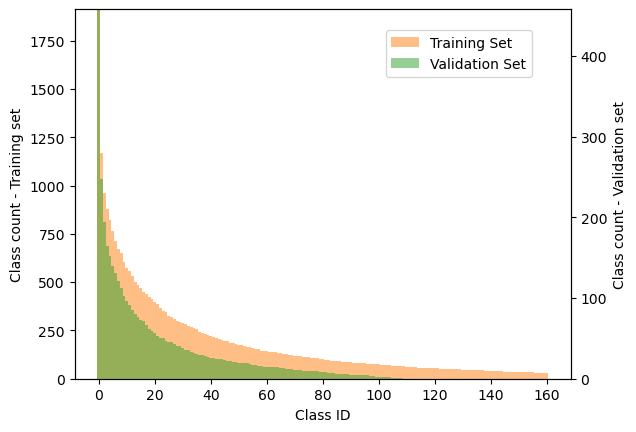

In [32]:
y_train = np.array(train.class_id.value_counts())[::10]
y_val = np.array(val.class_id.value_counts())[1::10]

fig, ax1 = plt.subplots()

# Create bar plot for y_train
bar1 = ax1.bar(np.arange(len(y_train)), y_train, width=1, color='tab:orange', alpha=0.5, label='Training Set')

# Create secondary y-axis
ax2 = ax1.twinx()

# Create bar plot for y_val on secondary y-axis
bar2 = ax2.bar(np.arange(len(y_val)), y_val, width=1, alpha=0.5, color='tab:green', label='Validation Set')

# Set the same peak for visual comparison
ax1.set_ylim(0, y_train.max())
ax2.set_ylim(0, y_val.max())

# Label axes
ax1.set_ylabel('Class count - Training set')
ax2.set_ylabel('Class count - Validation set')
ax1.set_xlabel('Class ID')

# Add legend
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85))

plt.show()

In [33]:
y_train.max()

1913